c:\Users\tomek\Documents\rental-long-stay-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Baseline model AUC: 0.4994


c:\Users\tomek\Documents\rental-long-stay-prediction\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best hyperparameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Advanced model AUC: 0.9628
Classification report for XGBoost:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93     26380
           1       0.85      0.91      0.88     14861

    accuracy                           0.91     41241
   macro avg       0.90      0.91      0.90     41241
weighted avg       0.91      0.91      0.91     41241



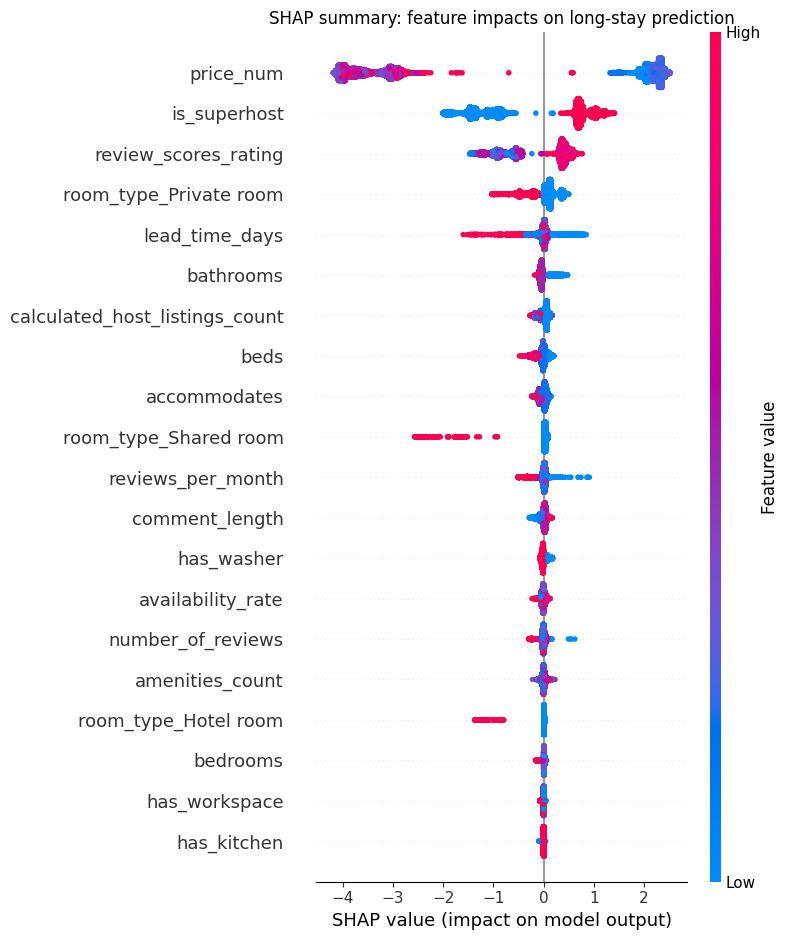

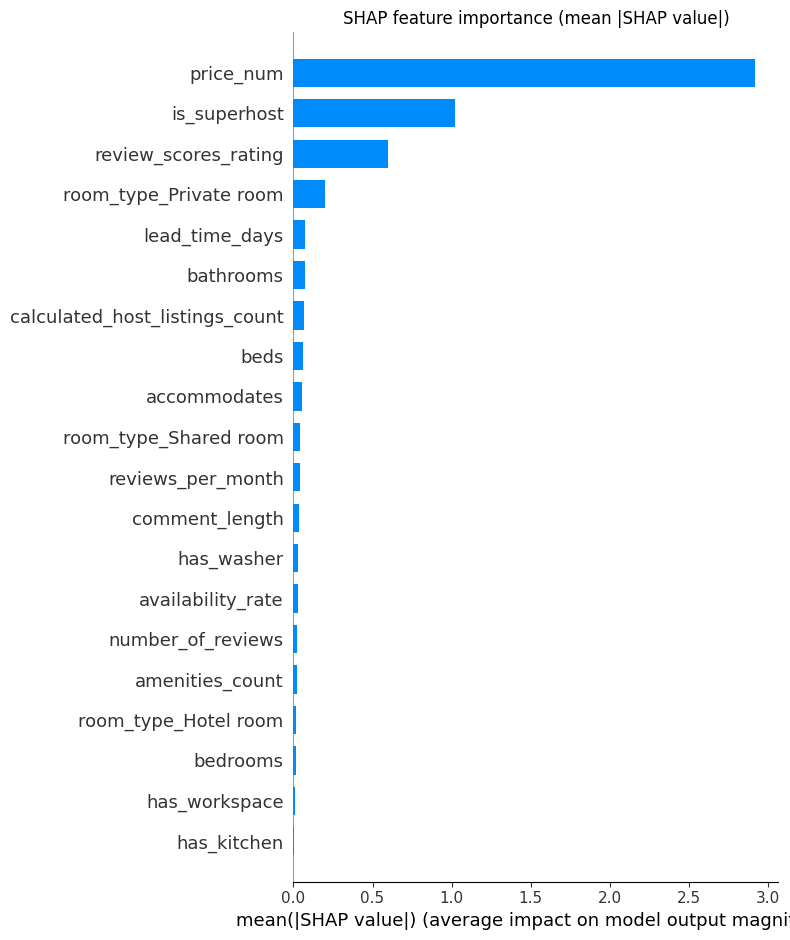

Models and feature names saved successfully.


In [1]:
import os
import pandas as pd
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report

os.makedirs('../src/models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df: pd.DataFrame = pd.read_csv('../data/processed/processed_data.csv')

groups: pd.Series = df['listing_id']
X: pd.DataFrame = df.drop(columns=['is_long_stay', 'listing_id'])
y: pd.Series = df['is_long_stay']

gss: GroupShuffleSplit = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train: pd.Series = groups.iloc[train_idx]

model_baseline: DummyClassifier = DummyClassifier(strategy='stratified', random_state=42)
model_baseline.fit(X_train, y_train)

y_prob_base = model_baseline.predict_proba(X_test)[:, 1]
base_auc: float = roc_auc_score(y_test, y_prob_base)
print(f"Baseline model AUC: {base_auc:.4f}")

xgb_model: xgb.XGBClassifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_distributions: dict = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

gkf: GroupKFold = GroupKFold(n_splits=3)

random_search: RandomizedSearchCV = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=15,
    scoring='roc_auc',
    cv=gkf,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train, groups=groups_train)
model_advanced: xgb.XGBClassifier = random_search.best_estimator_

print(f"Best hyperparameters: {random_search.best_params_}")

y_pred_adv = model_advanced.predict(X_test)
y_prob_adv = model_advanced.predict_proba(X_test)[:, 1]
adv_auc: float = roc_auc_score(y_test, y_prob_adv)

print(f"Advanced model AUC: {adv_auc:.4f}")
print("Classification report for XGBoost:\n", classification_report(y_test, y_pred_adv))

explainer: shap.TreeExplainer = shap.TreeExplainer(model_advanced)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP summary: feature impacts on long-stay prediction')
plt.tight_layout()
plt.savefig('../results/shap_summary_dot.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP feature importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('../results/shap_summary_bar.png', bbox_inches='tight')
plt.show()

joblib.dump(model_baseline, '../src/models/model_baseline.joblib')
joblib.dump(model_advanced, '../src/models/model_advanced.joblib')
joblib.dump(X.columns.tolist(), '../src/models/model_features.joblib')

print("Models and feature names saved successfully.")